In [1]:
import pandas as pd
import torch

In [2]:
# colab only
"""from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs("data", exist_ok=True)
"""

Mounted at /content/drive


In [3]:
"""import torch

print(torch.__version__)
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device count: {torch.cuda.device_count()}")"""

'import torch\n\nprint(torch.__version__)\nprint(f"CUDA available: {torch.cuda.is_available()}")\nprint(f"Device count: {torch.cuda.device_count()}")'

In [4]:
log_returns = pd.read_csv("data/log_returns.csv", index_col=0, parse_dates=True)
features = pd.read_csv("data/features_aligned.csv", index_col=0, parse_dates=True)
target = pd.read_csv("data/target.csv", index_col=0, parse_dates=True)

print(log_returns.shape)
print(features.shape)
print(target.shape)

# On Colab
"""BASE = "/content/drive/MyDrive/sp500-gnn/data"

log_returns = pd.read_csv(f"{BASE}/log_returns.csv", index_col=0, parse_dates=True)
features    = pd.read_csv(f"{BASE}/features_aligned.csv", index_col=0, parse_dates=True)
target      = pd.read_csv(f"{BASE}/target.csv", index_col=0, parse_dates=True)

print(log_returns.shape)
print(features.shape)
print(target.shape)"""

(2764, 462)
(2739, 2772)
(2739, 462)


In [5]:
TRAIN_END = "2022-12-31"
VAL_START = "2023-01-01"
VAL_END   = "2023-12-31"
TEST_START = "2024-01-01"

features_train = features.loc[:TRAIN_END]
features_val   = features.loc[VAL_START:VAL_END]
features_test  = features.loc[TEST_START:]

target_train = target.loc[:TRAIN_END]
target_val   = target.loc[VAL_START:VAL_END]
target_test  = target.loc[TEST_START:]

print(f"train: {features_train.shape}")
print(f"val:   {features_val.shape}")
print(f"test:  {features_test.shape}")

# Check column layout — critical for the Dataset class
print("\nFirst 12 columns:")
print(features.columns[:12].tolist())

train: (1993, 2772)
val:   (250, 2772)
test:  (496, 2772)

First 12 columns:
['A_roll_mean_5', 'A_roll_mean_20', 'A_roll_std_5', 'A_roll_std_20', 'A_mom_5', 'A_mom_20', 'AAPL_roll_mean_5', 'AAPL_roll_mean_20', 'AAPL_roll_std_5', 'AAPL_roll_std_20', 'AAPL_mom_5', 'AAPL_mom_20']


In [6]:
feat_mean = features_train.mean()
feat_std  = features_train.std().replace(0, 1)

features_train_n = (features_train - feat_mean) / feat_std
features_val_n   = (features_val   - feat_mean) / feat_std
features_test_n  = (features_test  - feat_mean) / feat_std

print("NaN in train after norm:", features_train_n.isna().sum().sum())
print("NaN in val after norm:  ", features_val_n.isna().sum().sum())

NaN in train after norm: 0
NaN in val after norm:   0


In [7]:
import numpy as np
from torch.utils.data import Dataset, DataLoader

class StockSequenceDataset(Dataset):
    """
    One sample = one (stock, time window) pair.
    X shape: (seq_len, num_features)
    y shape: (1,)

    Assumes features_aligned columns are in ticker-block order:
    [AAPL_feat1, AAPL_feat2, ..., MSFT_feat1, MSFT_feat2, ...]
    i.e. the first 6 columns all belong to the first ticker, etc.
    Verify with the Cell 5 column printout before running.
    """
    def __init__(self, feat_df, tgt_df, seq_len):
        tickers   = tgt_df.columns.tolist()
        num_feat  = feat_df.shape[1] // len(tickers)   # 2772 / 462 = 6

        xs, ys = [], []
        for i, ticker in enumerate(tickers):
            f = feat_df.iloc[:, i * num_feat : (i + 1) * num_feat].values  # (T, 6)
            t = tgt_df[ticker].values                                        # (T,)

            for step in range(seq_len, len(f)):
                window = f[step - seq_len : step]   # (seq_len, 6)
                label  = t[step]
                if np.isnan(window).any() or np.isnan(label):
                    continue
                xs.append(window)
                ys.append(label)

        self.X = torch.tensor(np.array(xs), dtype=torch.float32)
        self.y = torch.tensor(np.array(ys), dtype=torch.float32).unsqueeze(-1)
        print(f"  {len(self.X):,} samples | X: {self.X.shape} | y: {self.y.shape}")

    def __len__(self):          return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

In [8]:
SEQ_LEN    = 40
BATCH_SIZE = 512
HIDDEN_DIM = 128
NUM_LAYERS = 3
DROPOUT    = 0.2
LR         = 1e-3
MAX_EPOCHS = 20
PATIENCE   = 5

print("Building train dataset...")
ds_train = StockSequenceDataset(features_train_n, target_train, SEQ_LEN)
print("Building val dataset...")
ds_val   = StockSequenceDataset(features_val_n,   target_val,   SEQ_LEN)
print("Building test dataset...")
ds_test  = StockSequenceDataset(features_test_n,  target_test,  SEQ_LEN)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

Building train dataset...
  902,286 samples | X: torch.Size([902286, 40, 6]) | y: torch.Size([902286, 1])
Building val dataset...
  97,020 samples | X: torch.Size([97020, 40, 6]) | y: torch.Size([97020, 1])
Building test dataset...
  210,672 samples | X: torch.Size([210672, 40, 6]) | y: torch.Size([210672, 1])


In [9]:
import torch.nn as nn

DEVICE = torch.device("cuda")

class StockLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)            # (batch, seq_len, hidden)
        out    = self.dropout(out[:,-1]) # last timestep only
        return self.fc(out)              # (batch, 1)

NUM_FEATURES = ds_train.X.shape[-1]   # 6
model = StockLSTM(NUM_FEATURES, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(DEVICE)
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

StockLSTM(
  (lstm): LSTM(6, 128, num_layers=3, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
Parameters: 333,953


In [10]:
LR         = 1e-3
MAX_EPOCHS = 20
PATIENCE   = 5

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses, val_losses = [], []
best_val   = float("inf")
no_improve = 0
best_state = None

for epoch in range(1, MAX_EPOCHS + 1):
    # train
    model.train()
    total = 0.0
    for X_b, y_b in dl_train:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item() * len(X_b)
    train_loss = total / len(ds_train)

    # validate
    model.eval()
    total = 0.0
    with torch.no_grad():
        for X_b, y_b in dl_val:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            total += criterion(model(X_b), y_b).item() * len(X_b)
    val_loss = total / len(ds_val)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | train MSE: {train_loss:.6f} | val MSE: {val_loss:.6f}")

    # early stopping
    if val_loss < best_val - 1e-6:
        best_val   = val_loss
        no_improve = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stop at epoch {epoch} | best val MSE: {best_val:.6f}")
            break

model.load_state_dict(best_state)

Epoch   1 | train MSE: 0.001982 | val MSE: 0.001608
Epoch   5 | train MSE: 0.001688 | val MSE: 0.001632
Early stop at epoch 6 | best val MSE: 0.001608


<All keys matched successfully>

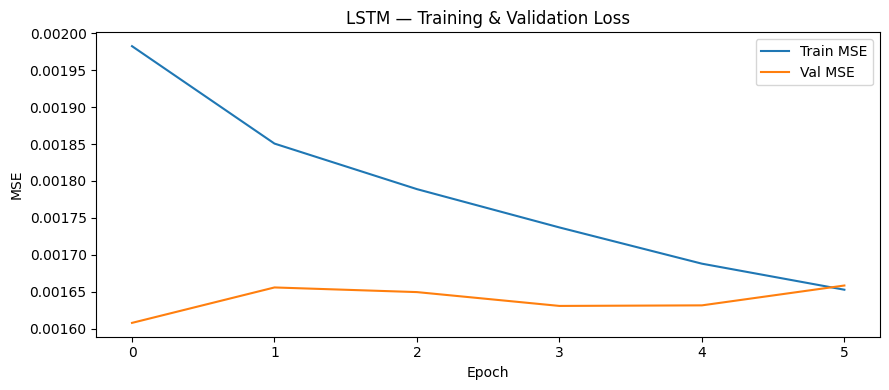

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.plot(train_losses, label="Train MSE")
plt.plot(val_losses,   label="Val MSE")
plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.title("LSTM — Training & Validation Loss")
plt.legend(); plt.tight_layout()
plt.savefig("data/lstm_loss_curve.png", dpi=150)
plt.show()

In [16]:
model.eval()
preds_list, true_list = [], []
with torch.no_grad():
    for X_b, y_b in dl_test:
        preds_list.append(model(X_b.to(DEVICE)).cpu().numpy())
        true_list.append(y_b.numpy())

preds = np.concatenate(preds_list).flatten()
trues = np.concatenate(true_list).flatten()

mse      = np.mean((preds - trues) ** 2)
rmse     = np.sqrt(mse)
dir_acc  = np.mean(np.sign(preds) == np.sign(trues))

print(f"Test MSE:             {mse:.6f}")
print(f"Test RMSE:            {rmse:.6f}")
print(f"Directional Accuracy: {dir_acc*100:.1f}%")

# Save for Phase 6 comparison
torch.save(best_state, "data/lstm_best_model.pt")
pd.DataFrame({"pred": preds, "true": trues}).to_csv("data/lstm_results.csv", index=False)
print("Saved lstm_best_model.pt + lstm_results.csv")

Test MSE:             0.001944
Test RMSE:            0.044087
Directional Accuracy: 49.9%
Saved lstm_best_model.pt + lstm_results.csv
